# 01 - GCN training
Graph Convolutional Network na datasecie Cora z własnymi splitami treningowymi.

In [9]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0]

print(f'Węzły:    {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Cechy:    {data.num_node_features}')
print(f'Klasy:    {dataset.num_classes}')
print(f'Train:    {data.train_mask.sum().item()}')
print(f'Val:      {data.val_mask.sum().item()}')
print(f'Test:     {data.test_mask.sum().item()}')

Węzły:    2708
Krawędzie: 10556
Cechy:    1433
Klasy:    7
Train:    140
Val:      500
Test:     1000


## Baseline GCN
Kipf & Welling (2017)

In [10]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

## Funkcje treningowe i testowe

In [11]:
def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

## Baseline - standardowy split Planetoid
Odtworzenie wyników z oryginalnego papieru Kipf & Welling (2017): 140 węzłów treningowych.

In [12]:
original_train_mask = data.train_mask.clone()

baseline_model = GCN(dataset.num_features, 64, dataset.num_classes)
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.01)

for epoch in range(200):
    loss = train(baseline_model, baseline_optimizer)
    if epoch % 20 == 0:
        acc = test(baseline_model)
        print(f'Epoch {epoch:3d}: Loss={loss:.4f}, Acc={acc:.4f}')

baseline_acc = test(baseline_model)
print(f'\nBaseline GCN (paper split): {baseline_acc:.4f}')
print(f'Paper (Kipf & Welling 2017): ~0.815')

Epoch   0: Loss=1.9486, Acc=0.6190
Epoch  20: Loss=0.0109, Acc=0.7950
Epoch  40: Loss=0.0006, Acc=0.7850
Epoch  60: Loss=0.0004, Acc=0.7840
Epoch  80: Loss=0.0004, Acc=0.7840
Epoch 100: Loss=0.0002, Acc=0.7820
Epoch 120: Loss=0.0003, Acc=0.7830
Epoch 140: Loss=0.0005, Acc=0.7870
Epoch 160: Loss=0.0042, Acc=0.7850
Epoch 180: Loss=0.0002, Acc=0.7830

Baseline GCN (paper split): 0.7850
Paper (Kipf & Welling 2017): ~0.815


## Własne splity treningowe
Mój wkład: testowanie wpływu liczby etykiet (5%, 10%, 20%) na accuracy.
Oryginalne papiery używały tylko stałego benchmarku

In [13]:
def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)

    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]

    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True

    return train_mask

# test
for ratio in [0.05, 0.10, 0.20]:
    mask = create_split(data, ratio)
    print(f'{ratio:.0%}: {mask.sum().item()} węzłów treningowych')

5%: 135 węzłów treningowych
10%: 270 węzłów treningowych
20%: 541 węzłów treningowych


## Eksperymenty - accuracy vs. liczba etykiet
Każdy scenariusz powtórzony 5 razy z różnymi seedami: średnia ± odchylenie standardowe

In [14]:
ratios = [0.05, 0.10, 0.20]
seeds  = [42, 123, 456, 789, 1000]
labels = ['5%', '10%', '20%']
results = defaultdict(list)
best_acc = 0

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)

        model = GCN(dataset.num_features, 64, dataset.num_classes)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        for epoch in range(200):
            train(model, optimizer)

        acc = test(model)
        results[ratio].append(acc)
        print(f'Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), '../models/gcn_best.pt')

# przywróć oryginalny split
data.train_mask = original_train_mask

print('\n--- Podsumowanie ---')
for ratio, accs in results.items():
    print(f'{ratio:.0%}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'Najlepszy model: {best_acc:.4f}')

Ratio: 5%, Seed: 42, Acc: 0.7900
Ratio: 5%, Seed: 123, Acc: 0.7980
Ratio: 5%, Seed: 456, Acc: 0.7750
Ratio: 5%, Seed: 789, Acc: 0.8170
Ratio: 5%, Seed: 1000, Acc: 0.7810
Ratio: 10%, Seed: 42, Acc: 0.8100
Ratio: 10%, Seed: 123, Acc: 0.7910
Ratio: 10%, Seed: 456, Acc: 0.8290
Ratio: 10%, Seed: 789, Acc: 0.8160
Ratio: 10%, Seed: 1000, Acc: 0.8300
Ratio: 20%, Seed: 42, Acc: 0.8410
Ratio: 20%, Seed: 123, Acc: 0.8060
Ratio: 20%, Seed: 456, Acc: 0.8340
Ratio: 20%, Seed: 789, Acc: 0.8140
Ratio: 20%, Seed: 1000, Acc: 0.8420

--- Podsumowanie ---
5%: 0.7922 ± 0.0147
10%: 0.8152 ± 0.0143
20%: 0.8274 ± 0.0147
Najlepszy model: 0.8420


## Wizualizacja wyników

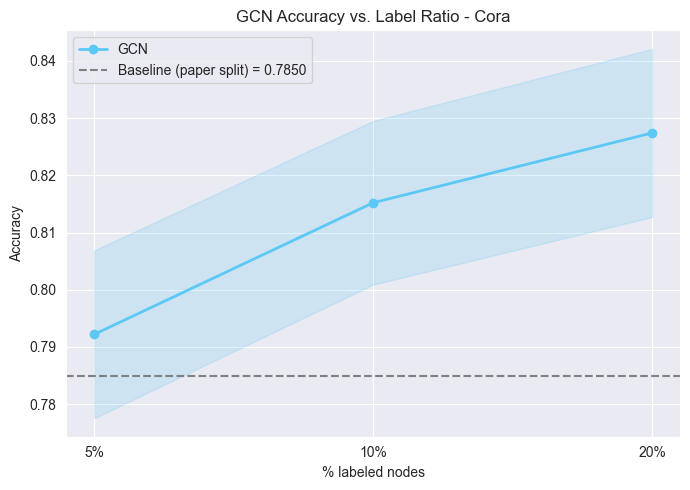

Wykres zapisany: ../results/gcn_label_ratio.png


In [17]:
means = [np.mean(results[r]) for r in ratios]
stds  = [np.std(results[r])  for r in ratios]

plt.figure(figsize=(7, 5))
plt.plot(labels, means, marker='o', color='#5BC8F5', linewidth=2, label='GCN')
plt.fill_between(labels,
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='#5BC8F5')
plt.axhline(y=baseline_acc, color='gray', linestyle='--',
            label=f'Baseline (paper split) = {baseline_acc:.4f}')
plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('GCN Accuracy vs. Label Ratio - Cora')
plt.legend()
plt.tight_layout()
plt.savefig('../results/gcn_label_ratio.png')
plt.show()
print('Wykres zapisany: ../results/gcn_label_ratio.png')

## Zapis wyników

In [16]:
results_serializable = {str(k): v for k, v in results.items()}
with open('../models/gcn_results.json', 'w') as f:
    json.dump(results_serializable, f, indent=2)

print('Zapisano:')
print('../models/gcn_results.json')
print('../models/gcn_best.pt')
print('../results/gcn_label_ratio.png')

Zapisano:
  ../models/gcn_results.json
  ../models/gcn_best.pt
  ../results/gcn_label_ratio.png
